In [1]:
import pandas as pd
import numpy as np

# Data cleaning

## clean wikipedia data

In [10]:
wikidata = pd.read_csv('../datasets/wikipedia.dat', sep='\t', header=None, names=['raw'])

In [11]:
# Identify canonical rows
wikidata["is_correct"] = wikidata["raw"].str.startswith("$")
wikidata

,raw,is_correct
0,$Apennines,True
1,Apenines,False
2,Appenines,False
3,$Athenian,True
4,Athenean,False
...,...,...
4372,eyars,False
4373,eyasr,False
4374,yeasr,False
4375,yeras,False


In [12]:

# Create a clean "correct" column and carry it down to misspelling rows
wikidata["correct"] = (
    wikidata["raw"]
    .where(wikidata["is_correct"])
    .str.replace(r"^\$", "", regex=True)
    .ffill()
)

wikidata

,raw,is_correct,correct
0,$Apennines,True,Apennines
1,Apenines,False,Apennines
2,Appenines,False,Apennines
3,$Athenian,True,Athenian
4,Athenean,False,Athenian
...,...,...,...
4372,eyars,False,years
4373,eyasr,False,years
4374,yeasr,False,years
4375,yeras,False,years


In [14]:
wiki_pairs = (
    wikidata.loc[~wikidata["is_correct"], ["correct", "raw"]]
    .rename(columns={"raw": "incorrect"})
    .reset_index(drop=True))

wiki_pairs

,correct,incorrect
0,Apennines,Apenines
1,Apennines,Appenines
2,Athenian,Athenean
3,Athenians,Atheneans
4,Bernoulli,Bernouilli
...,...,...
2450,years,eyars
2451,years,eyasr
2452,years,yeasr
2453,years,yeras


## import KidSpell data

In [16]:
ks_pairs = pd.read_csv('../datasets/Essay_Writing_Errors.csv')[['Target', 'Spelling']]

ks_pairs.head(5)

,Target,Spelling
0,favorite,favtit
1,throw,thow
2,catch,cach
3,touchdown,tuchdone
4,dance,dans


## Final set

In [49]:
final_pairs = pd.concat([wiki_pairs, ks_pairs.rename(columns={'Target': 'correct', 'Spelling': 'incorrect'})], ignore_index=True)
final_pairs = final_pairs.apply(lambda x: x.str.lower())
final_pairs.drop_duplicates(inplace=True)
final_pairs.dropna(inplace=True)
# drop rows where correct and incorrect are the same
final_pairs = final_pairs[final_pairs['correct'] != final_pairs['incorrect']]

In [50]:
final_pairs

,correct,incorrect
0,apennines,apenines
1,apennines,appenines
2,athenian,athenean
3,athenians,atheneans
4,bernoulli,bernouilli
...,...,...
3812,extremely,extremly
3814,success,sucsses
3815,safety,safty
3816,sincerely,sincerly


# Assign Labels

In [51]:
# ! pip install pronouncing

In [61]:
import re
from difflib import SequenceMatcher


def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", text.strip().lower())


def strip_spaces(text: str) -> str:
    return re.sub(r"\s+", "", normalize_text(text))


def letters_only(text: str) -> str:
    return re.sub(r"[^a-z]", "", normalize_text(text))

# rules from Downs et al. (2020): https://github.com/BSU-CAST/KidSpell/blob/master/KidSpell.py
PHONETIC_RULES = [
    (r"[^a-z]", r""),
    (r"(?<=^[rct])ough", r"F"),
    (r"(?<=^en)ough", r"F"),
    (r"^laugh", r"LF"),
    (r"(?<=[wc]ou)ld", r"D"),
    (r"([bdfhjklmnpqrstvwxyz])\1+", r"\1"),
    (r"cc", r"K"),
    (r"ck", r"K"),
    (r"^ocea", r"A2"),
    (r"^[aeiou]+", r"A"),
    (r"^[gkp]n", r"N"),
    (r"^wr", r"R"),
    (r"^x", r"S"),
    (r"^wh", r"W"),
    (r"^w", r"W"),
    (r"^gh", r"G"),
    (r"^rh", r"R"),
    (r"mb(?=ed|ing|ings|s|\b)", r"M"),
    (r"^sch", r"SK"),
    (r"th", r"0"),
    (r"^y", r"Y"),
    (r"t?ch", r"1"),
    (r"sh", r"2"),
    (r"c(?=ion|iou)", r"2"),
    (r"t(?=ure)", r"1"),
    (r"t(?=ual)", r"1"),
    (r"[st](?=i[ao])", r"2"),
    (r"s?c(?=[iey])", r"S"),
    (r"c", r"K"),
    (r"dg(?=e)", r"J"),
    (r"g(?=h[^aeiou])", r""),
    (r"gh(?=ed|ing|ee|ings|ees|s|\b)", r""),
    (r"gh", r"G"),
    (r"gn(?=ed|ing|ee|ings|ees|s|\b)", r"N"),
    (r"y$", r"Y"),
    (r"g+", r"G"),
    (r"ph", r"F"),
    (r"([aeiou])h(?=\b|[^aeiou])", r"\1"),
    (r"[wy](?=[^aeiou])", r""),
    (r"[aeiou]w", r""),
    (r"z", r"S"),
    (r"y", r""),
    (r"(?!^)[aeiou]+", r"")
]


def phonetic_key(text: str) -> str:
    key = normalize_text(text)
    for pattern, replacement in PHONETIC_RULES:
        key = re.sub(pattern, replacement, key)
    return key


def is_transposition(correct: str, incorrect: str) -> bool:
    correct = normalize_text(correct)
    incorrect = normalize_text(incorrect)

    if len(correct) != len(incorrect):
        return False

    diff_idx = [i for i, (c, d) in enumerate(zip(correct, incorrect)) if c != d]
    if len(diff_idx) != 2:
        return False

    i, j = diff_idx
    return (
        j == i + 1
        and correct[i] == incorrect[j]
        and correct[j] == incorrect[i]
    )


def is_phoneme_substitution(correct: str, incorrect: str, source_chunk: str = "", target_chunk: str = "") -> bool:
    correct_letters = letters_only(correct)
    incorrect_letters = letters_only(incorrect)

    if not correct_letters or not incorrect_letters or correct_letters == incorrect_letters:
        return False

    if source_chunk and target_chunk:
        source_letters = letters_only(source_chunk)
        target_letters = letters_only(target_chunk)
        if source_letters and target_letters and source_letters != target_letters:
            if phonetic_key(source_letters) == phonetic_key(target_letters):
                return True

    correct_key = phonetic_key(correct_letters)
    incorrect_key = phonetic_key(incorrect_letters)

    if correct_key == incorrect_key:
        return True

    return SequenceMatcher(None, correct_key, incorrect_key).ratio() >= 0.88


def classify_misspelling(correct: str, incorrect: str) -> str:
    correct_norm = normalize_text(str(correct))
    incorrect_norm = normalize_text(str(incorrect))

    error_types = []

    if (
        " " in correct_norm
        or " " in incorrect_norm
        or strip_spaces(correct_norm) == strip_spaces(incorrect_norm)
    ):
        error_types.append("word_boundary_or_multiword")

    if is_transposition(correct_norm, incorrect_norm):
        error_types.append("transposition")

    ops = SequenceMatcher(None, correct_norm, incorrect_norm).get_opcodes()
    non_equal_ops = [op for op in ops if op[0] != "equal"]

    if len(non_equal_ops) == 1:
        tag, i1, i2, j1, j2 = non_equal_ops[0]
        source_chunk = correct_norm[i1:i2]
        target_chunk = incorrect_norm[j1:j2]

        if tag == "delete":
            error_types.append("missing_letter")

        elif tag == "insert":
            error_types.append("extra_letter")

        elif tag == "replace":
            if is_phoneme_substitution(correct_norm, incorrect_norm, source_chunk, target_chunk):
                error_types.append("phoneme_substitution")
            else:
                error_types.append("substitution")

    else:
        if non_equal_ops:
            error_types.append("multiple_edits")

        if is_phoneme_substitution(correct_norm, incorrect_norm):
            error_types.append("phoneme_substitution")

    error_types = list(dict.fromkeys(error_types))

    if len(error_types) == 0:
        return "complex/multiple"

    if len(error_types) == 1:
        if error_types[0] == "multiple_edits":
            return "complex/multiple"
        return error_types[0]

    return "complex/multiple"

In [62]:
final_pairs["error_type"] = final_pairs.apply(
    lambda row: classify_misspelling(row["correct"], row["incorrect"]),
    axis=1
)

In [63]:
final_pairs

,correct,incorrect,error_type
0,apennines,apenines,missing_letter
1,apennines,appenines,complex/multiple
2,athenian,athenean,phoneme_substitution
3,athenians,atheneans,phoneme_substitution
4,bernoulli,bernouilli,extra_letter
...,...,...,...
3812,extremely,extremly,missing_letter
3814,success,sucsses,complex/multiple
3815,safety,safty,missing_letter
3816,sincerely,sincerly,missing_letter


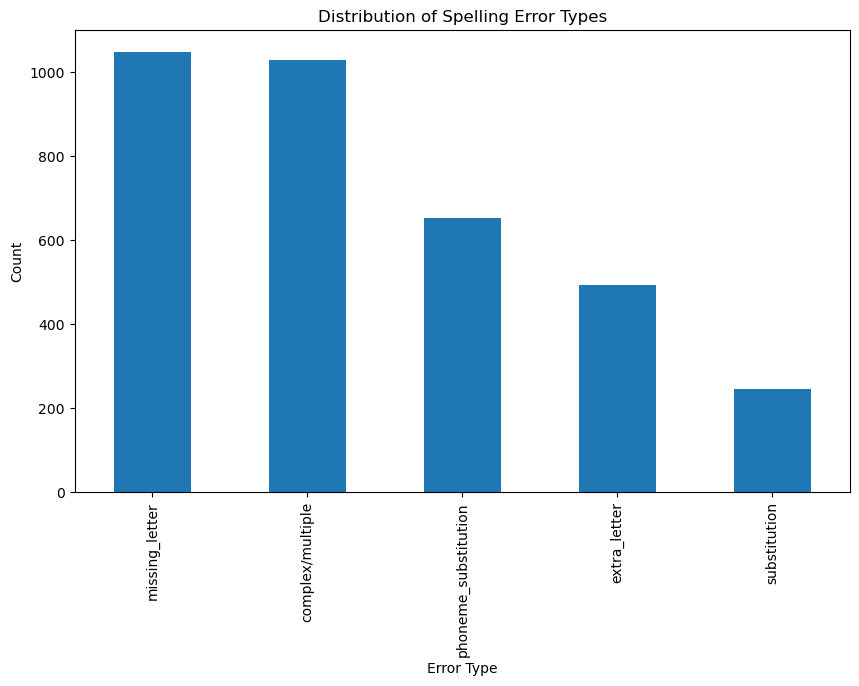

In [64]:
# visualize the distribution of error types
import matplotlib.pyplot as plt

error_type_counts = final_pairs["error_type"].value_counts()
plt.figure(figsize=(10, 6))
error_type_counts.plot(kind="bar")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.title("Distribution of Spelling Error Types")
plt.show()


In [66]:
final_pairs.to_excel('../datasets/final_pairs_with_error_labels_WIP_for_INSPECTIONs.xlsx', index=False)